In [ ]:
from google.colab import files
uploaded = files.upload()  # Select and upload rec_patch_data.xlsx
import pandas as pd
import numpy as np

df = pd.read_excel('rec_patch_data.xlsx')
print(df.head())
print(df.columns.tolist())

In [ ]:
X = df[['Freq(GHz)', 'length of patch in mm', 'width of patch in mm']]
y = df['s11(dB)']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
# Install necessary libraries if not already installed
!pip install catboost xgboost lightgbm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00


In [ ]:
import time
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

results = {}
predictions = {}

# LightGBM training
start = time.time()
lgbm = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=50, max_depth=12,
                         min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
                         reg_alpha=0.1, reg_lambda=0.1, random_state=42, n_jobs=-1)
lgbm.fit(X_train, y_train)
train_time = time.time() - start
pred = lgbm.predict(X_test)
pred_time = time.time() - (start + train_time)

results['LightGBM'] = [r2_score(y_test, pred), mean_squared_error(y_test, pred),
                      mean_absolute_error(y_test, pred), mean_absolute_percentage_error(y_test, pred)*100,
                      train_time, pred_time]
predictions['LightGBM'] = pred

# Similarly write for CatBoost, XGBoost, RandomForest, ExtraTrees
# (Use similar hyperparameters as discussed before)

# CatBoost
start = time.time()
cat = CatBoostRegressor(iterations=500, learning_rate=0.08, depth=10, l2_leaf_reg=3,
                        random_state=42, verbose=False)
cat.fit(X_train, y_train)
train_time = time.time() - start
pred = cat.predict(X_test)
pred_time = time.time() - (start + train_time)

results['CatBoost'] = [r2_score(y_test, pred), mean_squared_error(y_test, pred),
                      mean_absolute_error(y_test, pred), mean_absolute_percentage_error(y_test, pred)*100,
                      train_time, pred_time]
predictions['CatBoost'] = pred

# XGBoost
start = time.time()
xgb = XGBRegressor(n_estimators=400, learning_rate=0.08, max_depth=10, subsample=0.8,
                   colsample_bytree=0.8, random_state=42, verbosity=0, n_jobs=-1)
xgb.fit(X_train, y_train)
train_time = time.time() - start
pred = xgb.predict(X_test)
pred_time = time.time() - (start + train_time)

results['XGBoost'] = [r2_score(y_test, pred), mean_squared_error(y_test, pred),
                     mean_absolute_error(y_test, pred), mean_absolute_percentage_error(y_test, pred)*100,
                     train_time, pred_time]
predictions['XGBoost'] = pred

# Random Forest
start = time.time()
rf = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_split=5, min_samples_leaf=2,
                           random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
train_time = time.time() - start
pred = rf.predict(X_test)
pred_time = time.time() - (start + train_time)

results['RandomForest'] = [r2_score(y_test, pred), mean_squared_error(y_test, pred),
                          mean_absolute_error(y_test, pred), mean_absolute_percentage_error(y_test, pred)*100,
                          train_time, pred_time]
predictions['RandomForest'] = pred

# Extra Trees
start = time.time()
et = ExtraTreesRegressor(n_estimators=300, max_depth=15, min_samples_split=5, min_samples_leaf=2,
                         random_state=42, n_jobs=-1)
et.fit(X_train, y_train)
train_time = time.time() - start
pred = et.predict(X_test)
pred_time = time.time() - (start + train_time)

results['ExtraTrees'] = [r2_score(y_test, pred), mean_squared_error(y_test, pred),
                        mean_absolute_error(y_test, pred), mean_absolute_percentage_error(y_test, pred)*100,
                        train_time, pred_time]
predictions['ExtraTrees'] = pred

print("Training complete for all models.")
print(results)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035232 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 279
[LightGBM] [Info] Number of data points in the train set: 8808, number of used features: 3
[LightGBM] [Info] Start training from score -1.694414
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

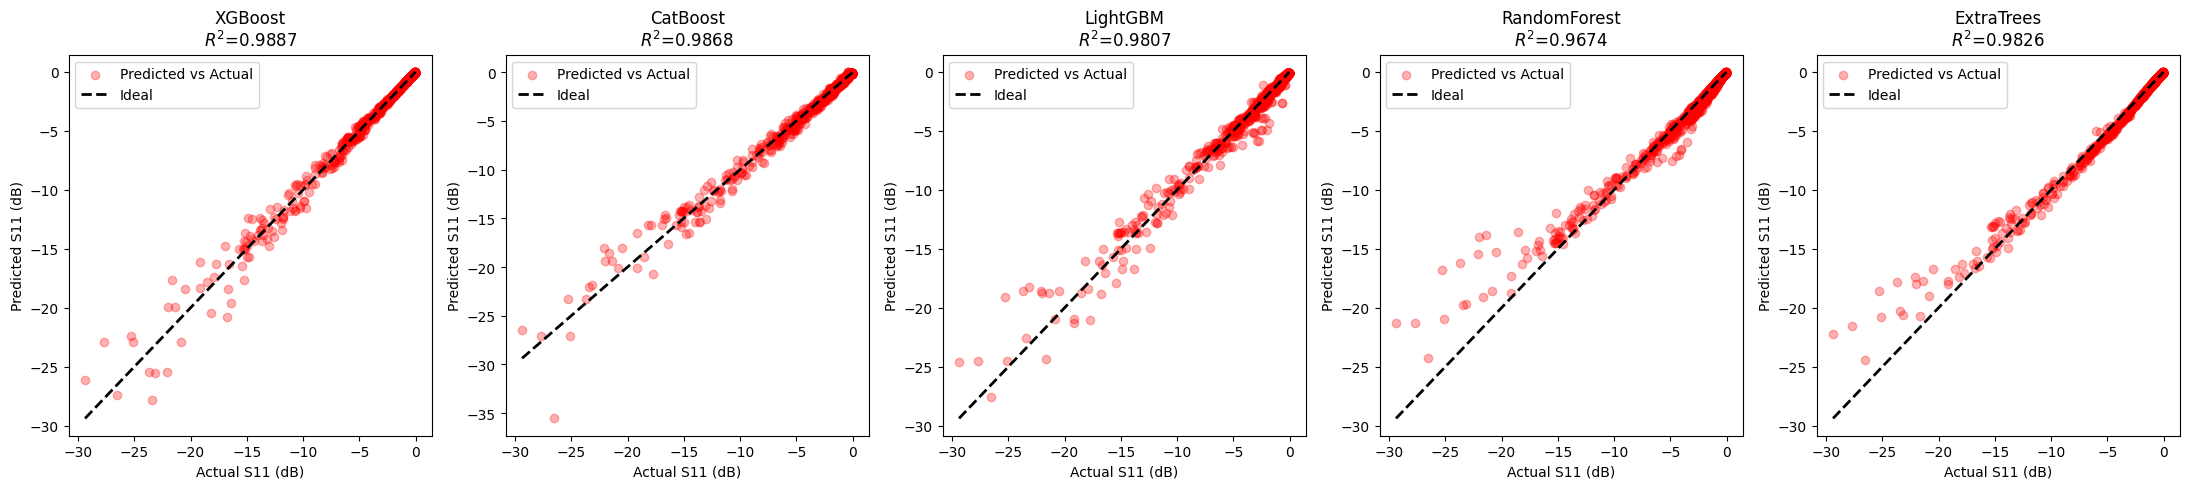

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 5))
model_list = ['XGBoost', 'CatBoost', 'LightGBM', 'RandomForest', 'ExtraTrees']

for i, model in enumerate(model_list, 1):
    plt.subplot(1, 5, i)
    plt.scatter(y_test, predictions[model], alpha=0.3, color='red', label='Predicted vs Actual')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal')
    plt.xlabel('Actual S11 (dB)')
    plt.ylabel('Predicted S11 (dB)')
    plt.title(f"{model}\n$R^2$={results[model][0]:.4f}")
    plt.legend()
plt.tight_layout()
plt.show()

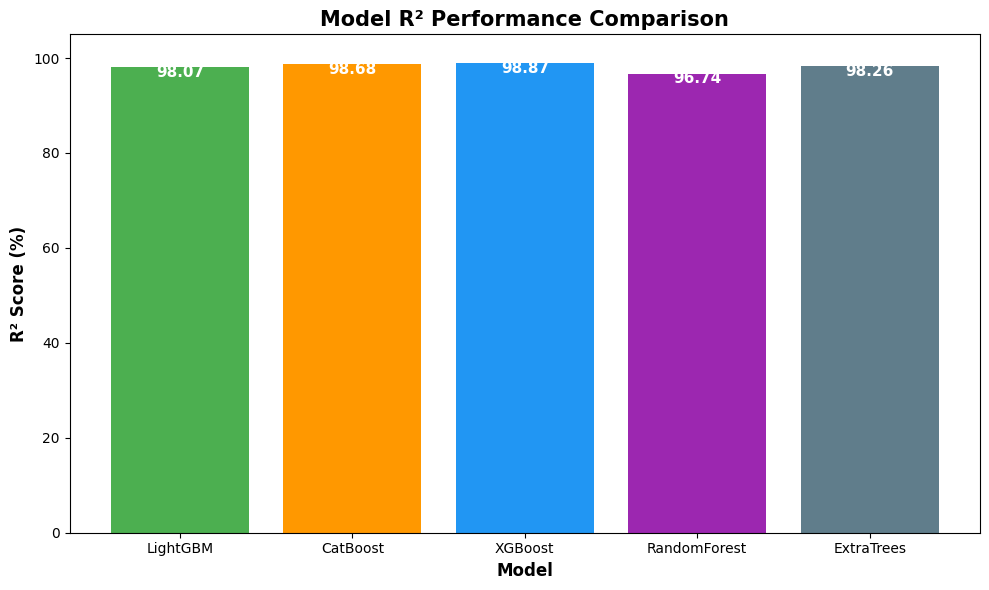

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

model_names = list(results.keys())
r2_scores = [results[m][0]*100 for m in model_names]  # R^2 as percent

plt.figure(figsize=(10,6))
bars = plt.bar(model_names, r2_scores, color=['#4caf50', '#ff9800', '#2196f3', '#9c27b0', '#607d8b'])
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('R² Score (%)', fontsize=12, fontweight='bold')
plt.title('Model R² Performance Comparison', fontsize=15, fontweight='bold')
plt.ylim(0, 105)
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() - 2, f'{b.get_height():.2f}', ha='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

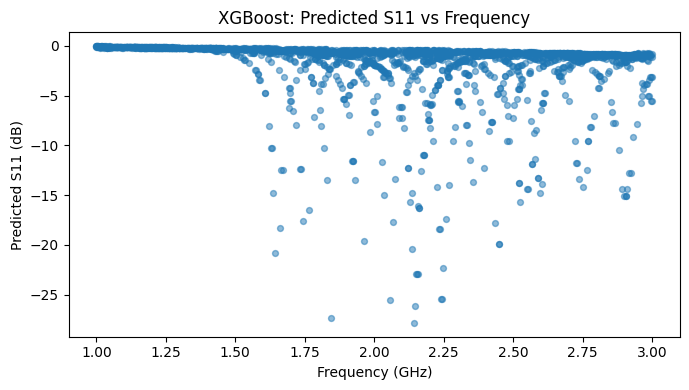

In [ ]:
plt.figure(figsize=(7,4))
plt.scatter(X_test['Freq(GHz)'], predictions['XGBoost'], s=18, alpha=0.5)
plt.xlabel('Frequency (GHz)')
plt.ylabel('Predicted S11 (dB)')
plt.title('XGBoost: Predicted S11 vs Frequency')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Build summary DataFrame
model_names = list(results.keys())
columns = ['R2', 'MSE', 'MAE', 'MAPE', 'Fit Time (s)', 'Prediction Time (s)']
summary_df = pd.DataFrame([results[m] for m in model_names], columns=columns, index=model_names)
summary_df.index.name = 'Model'

# Save as CSV
summary_df.to_csv('ML_Model_Performance.csv')
print("CSV exported as ML_Model_Performance.csv")
from google.colab import files
files.download('ML_Model_Performance.csv')

CSV exported as ML_Model_Performance.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
input_data_1 = {
    'Freq(GHz)': 1.75,
    'length of patch in mm': 39.91,
    'width of patch in mm': 51.19
}

import pandas as pd
input_df = pd.DataFrame([input_data_1])

# Predict using trained 3-input XGBoost model
predicted_s11 = xgb.predict(input_df)[0]

print(f"Predicted S11 (Return Loss) for input design: {predicted_s11:.2f} dB")


Predicted S11 (Return Loss) for input design: -30.61 dB


In [ ]:
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

freq = widgets.FloatText(value=2.146, description='Freq (GHz):')
length = widgets.FloatText(value=32.87, description='Patch Len (mm):')
width = widgets.FloatText(value=41.88, description='Patch Wid (mm):')
output = widgets.Output()
inputs = widgets.VBox([freq, length, width])
button = widgets.Button(description="Predict S11", button_style='success', layout=widgets.Layout(width='150px'))

def on_button_clicked(b):
    input_values = {
        'Freq(GHz)': freq.value,
        'length of patch in mm': length.value,
        'width of patch in mm': width.value
    }
    test_df = pd.DataFrame([input_values])
    # Use the globally defined xgb model for prediction
    pred = xgb.predict(test_df)[0]
    output.clear_output()
    with output:
        print(f"Predicted S11 (return loss) for this input: {pred:.2f} dB")

button.on_click(on_button_clicked)
display(inputs, button, output)

Button(button_style='success', description='Predict S11', layout=Layout(width='150px'), style=ButtonStyle())

Output()